<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Mapas%20auto%20organizaveis/Detec%C3%A7%C3%A3o_de_outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
!pip install minisom

In [28]:
import minisom
import pandas as pd
import numpy as np
import sklearn
import matplotlib

In [29]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib.pylab import pcolor, colorbar, plot
from minisom import MiniSom

In [30]:
base = pd.read_csv("/content/credit_data.csv")

In [31]:
base

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [32]:
base.isna().sum()

,0
clientid,0
income,0
age,3
loan,0
default,0


In [33]:
base = base.dropna()

In [34]:
base.isna().sum()

,0
clientid,0
income,0
age,0
loan,0
default,0


In [35]:
base.loc[base["age"] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [36]:
base["age"].mean()

np.float64(40.80755937840458)

In [37]:
base.loc[base["age"] > 0].mean()

,0
clientid,1003.431795
income,45328.856915
age,40.927700
loan,4443.240892
default,0.141926


In [38]:
base.loc[base.age < 0, "age"] = 40.92

In [39]:
X = base.iloc[:,0:4].values
y = base.iloc[:, 4].values

In [40]:
X

array([[1.00000000e+00, 6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [2.00000000e+00, 3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [3.00000000e+00, 5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [1.99800000e+03, 4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [1.99900000e+03, 4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [2.00000000e+03, 6.94365796e+04, 5.61526170e+01, 7.37883360e+03]])

In [41]:
normalizador = MinMaxScaler(feature_range = (0, 1))
X = normalizador.fit_transform(X)
X

array([[0.00000000e+00, 9.23175898e-01, 8.92091749e-01, 5.88837391e-01],
       [5.00250125e-04, 2.88121646e-01, 6.54707879e-01, 4.76826954e-01],
       [1.00050025e-03, 7.46334292e-01, 9.81188803e-01, 5.82620111e-01],
       ...,
       [9.98999500e-01, 4.86122016e-01, 2.16958067e-01, 4.01128949e-01],
       [9.99499750e-01, 4.75009983e-01, 1.00000000e+00, 1.17790295e-01],
       [1.00000000e+00, 9.88813673e-01, 8.29709134e-01, 5.35970280e-01]])

In [42]:
X.shape

(1997, 4)

In [43]:
som = MiniSom(x = 15, y = 15, input_len = 4, random_seed = 0)
som.random_weights_init(X)
som.train_random(data = X, num_iteration= 100)

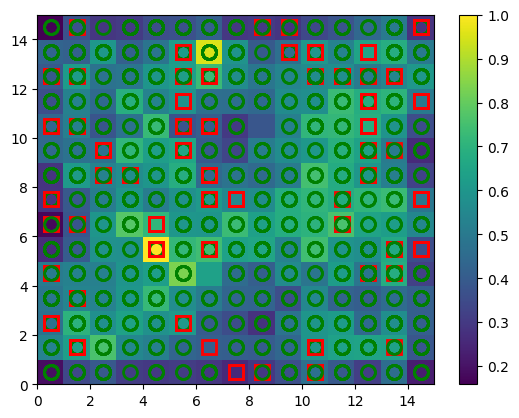

In [47]:
pcolor(som.distance_map().T)
colorbar()

markers = ["o", "s"]
colors = ["r", "g"]

for i, x in enumerate(X):
  w = som.winner(x)
  plot(w[0] + 0.5, w[1] + 0.5, markers[y[i]],
       markerfacecolor = "None", markersize = 10,
       markeredgecolor = colors[y[i] - 1], markeredgewidth = 2)

In [50]:
mapeamento = som.win_map(X)

In [57]:
suspeitos = np.concatenate((mapeamento[(4, 5)], mapeamento[(6, 13)]), axis = 0)
suspeitos

array([[0.60030015, 0.89212414, 0.32682387, 0.81827683],
       [0.68934467, 0.99519088, 0.57688264, 1.        ],
       [0.71785893, 0.83675961, 0.25024275, 0.79701105],
       [0.7833917 , 0.93890061, 0.09768899, 0.89934912],
       [0.7863932 , 0.89936976, 0.22484469, 0.83506183],
       [0.7923962 , 0.94585764, 0.18886874, 0.97172083],
       [0.8084042 , 0.96683576, 0.3545402 , 0.93277323],
       [0.83391696, 0.91833222, 0.10309697, 0.94234278],
       [0.16208104, 0.84084423, 0.95814162, 0.55520775],
       [0.17208604, 0.83600631, 0.84724841, 0.40813463],
       [0.17858929, 0.80245223, 0.97686696, 0.5222044 ],
       [0.20210105, 0.85110366, 0.99898032, 0.33711858],
       [0.24062031, 0.72564276, 0.96511268, 0.59675812],
       [0.24212106, 0.71866914, 0.92994809, 0.40987548],
       [0.24912456, 0.58222493, 0.9457653 , 0.46404825],
       [0.26813407, 0.62237741, 0.88142384, 0.47006204],
       [0.28414207, 0.72220061, 0.97512053, 0.67924811],
       [0.30115058, 0.80089704,

In [58]:
suspeitos = normalizador.inverse_transform(suspeitos)
suspeitos

array([[1.20100000e+03, 6.46039209e+04, 3.30618318e+01, 1.12646912e+04],
       [1.37900000e+03, 6.97553202e+04, 4.45436823e+01, 1.37660512e+04],
       [1.43600000e+03, 6.18367356e+04, 2.95454866e+01, 1.09719746e+04],
       [1.56700000e+03, 6.69418649e+04, 2.25407356e+01, 1.23806247e+04],
       [1.57300000e+03, 6.49660656e+04, 2.83792937e+01, 1.14957311e+04],
       [1.58500000e+03, 6.72895857e+04, 2.67274005e+01, 1.33767977e+04],
       [1.61700000e+03, 6.83380974e+04, 3.43344715e+01, 1.28406967e+04],
       [1.66800000e+03, 6.59138320e+04, 2.27890518e+01, 1.29724184e+04],
       [3.25000000e+02, 6.20408896e+04, 6.20498010e+01, 7.64363105e+03],
       [3.45000000e+02, 6.17990850e+04, 5.69579610e+01, 5.61921760e+03],
       [3.58000000e+02, 6.01220116e+04, 6.29096049e+01, 7.18935074e+03],
       [4.05000000e+02, 6.25536684e+04, 6.39249756e+01, 4.64170478e+03],
       [4.82000000e+02, 5.62829825e+04, 6.23698886e+01, 8.21555838e+03],
       [4.85000000e+02, 5.59344326e+04, 6.07552498e

In [59]:
classe = []
for i in range(len(base)):
  for j in range(len(suspeitos)):
    if base.iloc[i, 0] == int(round(suspeitos[j, 0])):
      classe.append(base.iloc[i, 4])
classe = np.asarray(classe)

In [60]:
classe, classe.shape

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1]), (19,))

In [65]:
suspeitos_final = np.column_stack((suspeitos, classe))
suspeitos_final

array([[1.20100000e+03, 6.46039209e+04, 3.30618318e+01, 1.12646912e+04,
        0.00000000e+00],
       [1.37900000e+03, 6.97553202e+04, 4.45436823e+01, 1.37660512e+04,
        0.00000000e+00],
       [1.43600000e+03, 6.18367356e+04, 2.95454866e+01, 1.09719746e+04,
        0.00000000e+00],
       [1.56700000e+03, 6.69418649e+04, 2.25407356e+01, 1.23806247e+04,
        0.00000000e+00],
       [1.57300000e+03, 6.49660656e+04, 2.83792937e+01, 1.14957311e+04,
        0.00000000e+00],
       [1.58500000e+03, 6.72895857e+04, 2.67274005e+01, 1.33767977e+04,
        0.00000000e+00],
       [1.61700000e+03, 6.83380974e+04, 3.43344715e+01, 1.28406967e+04,
        0.00000000e+00],
       [1.66800000e+03, 6.59138320e+04, 2.27890518e+01, 1.29724184e+04,
        0.00000000e+00],
       [3.25000000e+02, 6.20408896e+04, 6.20498010e+01, 7.64363105e+03,
        0.00000000e+00],
       [3.45000000e+02, 6.17990850e+04, 5.69579610e+01, 5.61921760e+03,
        0.00000000e+00],
       [3.58000000e+02, 6.0122

In [66]:
suspeitos_final = suspeitos_final[suspeitos_final[:, 4].argsort()]

In [69]:
suspeitos_final

array([[1.20100000e+03, 6.46039209e+04, 3.30618318e+01, 1.12646912e+04,
        0.00000000e+00],
       [1.37900000e+03, 6.97553202e+04, 4.45436823e+01, 1.37660512e+04,
        0.00000000e+00],
       [1.43600000e+03, 6.18367356e+04, 2.95454866e+01, 1.09719746e+04,
        0.00000000e+00],
       [1.56700000e+03, 6.69418649e+04, 2.25407356e+01, 1.23806247e+04,
        0.00000000e+00],
       [1.57300000e+03, 6.49660656e+04, 2.83792937e+01, 1.14957311e+04,
        0.00000000e+00],
       [1.58500000e+03, 6.72895857e+04, 2.67274005e+01, 1.33767977e+04,
        0.00000000e+00],
       [1.61700000e+03, 6.83380974e+04, 3.43344715e+01, 1.28406967e+04,
        0.00000000e+00],
       [1.66800000e+03, 6.59138320e+04, 2.27890518e+01, 1.29724184e+04,
        0.00000000e+00],
       [3.25000000e+02, 6.20408896e+04, 6.20498010e+01, 7.64363105e+03,
        0.00000000e+00],
       [3.45000000e+02, 6.17990850e+04, 5.69579610e+01, 5.61921760e+03,
        0.00000000e+00],
       [3.58000000e+02, 6.0122

In [70]:
suspeitos_final[:, 0] = np.round(suspeitos_final[:, 0].astype(int))

In [72]:
suspeitos_final[:, 0]

array([1201., 1379., 1436., 1567., 1573., 1585., 1617., 1668.,  325.,
        345.,  358.,  482.,  405.,  485.,  499.,  537.,  569.,  603.,
        662.])